# Predictive Uncertainty and Calibration

This notebook summarizes q300 predictive-interval diagnostics across the four main evaluation windows.

The core diagnostics are 90% interval coverage, interval width, interval score, bid-ask inclusion, and moneyness-region performance.

In [8]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

In [9]:
def find_project_root(start=None):
    here = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


def project_relative(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
COMMON_EVAL_ROOT = OUTPUTS_DIR / "common_eval_q160_eval300"
NONOVERLAP_ROOT = OUTPUTS_DIR / "nonoverlap_q160_eval300"

ANALYSIS_DIR = OUTPUTS_DIR / "comparisons" / "predictive_uncertainty_calibration"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.10
HAC_LAG = 5
SEEDS = [123, 456, 789, 101112, 131415]
MODEL_ORDER = ["Markovian SABR", "Rough-SABR"]
MODEL_COLORS = {"Markovian SABR": "#4c78a8", "Rough-SABR": "#d65225"}
MODEL_LABEL_MAP = {
    "Normal": "Markovian SABR",
    "Markovian": "Markovian SABR",
    "Rough": "Rough-SABR",
}

def normalize_model_labels(df):
    if "model" in df.columns:
        df["model"] = df["model"].replace(MODEL_LABEL_MAP)
    return df

WINDOWS = [
    {
        "key": "w0_400",
        "label": "0-399",
        "base": COMMON_EVAL_ROOT,
        "normal_pattern": "normal_400ts_q160_eval300_seed{seed}",
        "rough_pattern": "rough_400ts_q160_eval300_seed{seed}",
    },
    {
        "key": "w401_800",
        "label": "400-799",
        "base": NONOVERLAP_ROOT / "w401_800",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w801_1200",
        "label": "800-1199",
        "base": NONOVERLAP_ROOT / "w801_1200",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w1201_1600",
        "label": "1200-1599",
        "base": NONOVERLAP_ROOT / "w1201_1600",
        "normal_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
]
WINDOW_ORDER = [window["key"] for window in WINDOWS]
WINDOW_LABELS = {window["key"]: window["label"] for window in WINDOWS}

## Build Or Load Calibration Metrics

The cache stores timestamp-level and moneyness-region summaries so reruns do not always need to reload all quote-level prediction files.

In [10]:
PREDICTION_FILE = "predictive_option_prices_eval.csv"
TIMESTAMP_CACHE = TABLE_DIR / "predictive_calibration_timestamp_metrics.csv"
MONEYNESS_CACHE = TABLE_DIR / "predictive_calibration_moneyness_metrics.csv"
USE_CACHE = True

USECOLS = [
    "capture_time_utc",
    "t_index",
    "instrument_name",
    "T_years",
    "time_to_expiry_years",
    "market_price",
    "bid_price",
    "ask_price",
    "log_moneyness",
    "predictive_price_mean",
    "predictive_price_std",
    "predictive_price_q05",
    "predictive_price_q95",
    "predictive_price_error_vs_market",
    "predictive_mean_inside_bidask",
]
NUMERIC_COLS = [
    "t_index",
    "T_years",
    "time_to_expiry_years",
    "market_price",
    "bid_price",
    "ask_price",
    "log_moneyness",
    "predictive_price_mean",
    "predictive_price_std",
    "predictive_price_q05",
    "predictive_price_q95",
    "predictive_price_error_vs_market",
]


def interval_score(y, lower, upper, alpha=0.10):
    width = upper - lower
    below_penalty = (2.0 / alpha) * (lower - y) * (y < lower)
    above_penalty = (2.0 / alpha) * (y - upper) * (y > upper)
    return width + below_penalty + above_penalty


def as_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    return series.astype(str).str.lower().isin(["true", "1", "yes"])


def run_specs():
    for window in WINDOWS:
        for seed in SEEDS:
            yield {
                "window_key": window["key"],
                "window": window["label"],
                "model": "Markovian SABR",
                "seed": seed,
                "path": window["base"] / window["normal_pattern"].format(seed=seed),
            }
            yield {
                "window_key": window["key"],
                "window": window["label"],
                "model": "Rough-SABR",
                "seed": seed,
                "path": window["base"] / window["rough_pattern"].format(seed=seed),
            }


def summarize_run(spec):
    path = spec["path"] / PREDICTION_FILE
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, usecols=lambda c: c in USECOLS)
    missing = sorted(set(USECOLS) - set(df.columns))
    if missing:
        raise ValueError(f"{project_relative(path)} is missing required columns: {missing}")

    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    maturity = df["T_years"].where(df["T_years"].notna(), df["time_to_expiry_years"])
    df["maturity_days"] = 365.0 * pd.to_numeric(maturity, errors="coerce")
    df["abs_log_moneyness"] = df["log_moneyness"].abs()
    df["moneyness_region"] = pd.cut(
        df["abs_log_moneyness"],
        bins=[0.0, 0.05, 0.15, np.inf],
        labels=["Near ATM", "Intermediate", "Wing"],
        include_lowest=True,
        right=True,
    )

    lower = df["predictive_price_q05"]
    upper = df["predictive_price_q95"]
    y = df["market_price"]
    mean = df["predictive_price_mean"]
    df["covered_90"] = ((y >= lower) & (y <= upper)).astype(float)
    df["interval_width_90"] = upper - lower
    df["interval_score_90"] = interval_score(y, lower, upper, alpha=ALPHA)
    df["error"] = mean - y
    df["abs_error"] = df["error"].abs()
    df["squared_error"] = df["error"] ** 2
    df["inside_bidask"] = as_bool(df["predictive_mean_inside_bidask"]).astype(float)

    common = {
        "window_key": spec["window_key"],
        "window": spec["window"],
        "model": spec["model"],
        "seed": spec["seed"],
    }

    timestamp = (
        df.groupby("t_index", as_index=False)
        .agg(
            capture_time_utc=("capture_time_utc", "first"),
            n_quotes=("instrument_name", "size"),
            coverage_90=("covered_90", "mean"),
            interval_width_90=("interval_width_90", "mean"),
            interval_score_90=("interval_score_90", "mean"),
            mean_abs_error=("abs_error", "mean"),
            mean_squared_error=("squared_error", "mean"),
            inside_bidask_rate=("inside_bidask", "mean"),
            mean_predictive_std=("predictive_price_std", "mean"),
            mean_maturity_days=("maturity_days", "mean"),
            wing_quote_share=("moneyness_region", lambda s: (s.astype(str) == "Wing").mean()),
        )
        .assign(**common)
    )
    timestamp["rmse"] = np.sqrt(timestamp["mean_squared_error"])

    moneyness = (
        df.groupby("moneyness_region", observed=True)
        .agg(
            n_quote_instances=("instrument_name", "size"),
            coverage_90=("covered_90", "mean"),
            interval_width_90=("interval_width_90", "mean"),
            interval_score_90=("interval_score_90", "mean"),
            mean_abs_error=("abs_error", "mean"),
            mean_squared_error=("squared_error", "mean"),
            inside_bidask_rate=("inside_bidask", "mean"),
            mean_predictive_std=("predictive_price_std", "mean"),
        )
        .reset_index()
        .assign(**common)
    )
    moneyness["rmse"] = np.sqrt(moneyness["mean_squared_error"])
    return timestamp, moneyness


if USE_CACHE and TIMESTAMP_CACHE.exists() and MONEYNESS_CACHE.exists():
    timestamp_metrics = pd.read_csv(TIMESTAMP_CACHE)
    moneyness_metrics = pd.read_csv(MONEYNESS_CACHE)
    timestamp_metrics = normalize_model_labels(timestamp_metrics)
    moneyness_metrics = normalize_model_labels(moneyness_metrics)
else:
    timestamp_parts = []
    moneyness_parts = []
    for spec in run_specs():
        timestamp, moneyness = summarize_run(spec)
        timestamp_parts.append(timestamp)
        moneyness_parts.append(moneyness)
    timestamp_metrics = pd.concat(timestamp_parts, ignore_index=True)
    moneyness_metrics = pd.concat(moneyness_parts, ignore_index=True)
    timestamp_metrics.to_csv(TIMESTAMP_CACHE, index=False)
    moneyness_metrics.to_csv(MONEYNESS_CACHE, index=False)

timestamp_metrics["window_key"] = pd.Categorical(timestamp_metrics["window_key"], categories=WINDOW_ORDER, ordered=True)
timestamp_metrics["model"] = pd.Categorical(timestamp_metrics["model"], categories=MODEL_ORDER, ordered=True)
moneyness_metrics["window_key"] = pd.Categorical(moneyness_metrics["window_key"], categories=WINDOW_ORDER, ordered=True)
moneyness_metrics["model"] = pd.Categorical(moneyness_metrics["model"], categories=MODEL_ORDER, ordered=True)

print(f"Timestamp metrics: {len(timestamp_metrics):,} rows")
print(f"Moneyness metrics: {len(moneyness_metrics):,} rows")
display(timestamp_metrics.head())

Timestamp metrics: 16,000 rows
Moneyness metrics: 120 rows


,t_index,capture_time_utc,n_quotes,coverage_90,interval_width_90,interval_score_90,mean_abs_error,mean_squared_error,inside_bidask_rate,mean_predictive_std,mean_maturity_days,wing_quote_share,window_key,window,model,seed,rmse
0,0,2026-05-26T13:25:12+0000,290,0.796552,0.010083,0.010887,0.001135,0.000004,0.472414,0.003096,18.468411,0.268966,w0_400,0-399,Markovian SABR,123,0.001946
1,1,2026-05-26T13:30:12+0000,290,0.806897,0.005358,0.006261,0.001004,0.000002,0.500000,0.001623,18.464936,0.268966,w0_400,0-399,Markovian SABR,123,0.001314
2,2,2026-05-26T13:33:28+0000,290,0.782759,0.004334,0.005402,0.000879,0.000002,0.427586,0.001312,18.462675,0.268966,w0_400,0-399,Markovian SABR,123,0.001336
3,3,2026-05-26T13:38:28+0000,290,0.513793,0.004297,0.008067,0.001712,0.000006,0.265517,0.001316,18.459201,0.268966,w0_400,0-399,Markovian SABR,123,0.002448
4,4,2026-05-26T13:43:28+0000,290,0.582759,0.004821,0.007285,0.001798,0.000006,0.196552,0.001496,18.455726,0.268966,w0_400,0-399,Markovian SABR,123,0.002529


## Overall Calibration Summary

Coverage should be interpreted together with interval width and interval score. Lower interval scores are better.

In [11]:
def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    weights = pd.to_numeric(weights, errors="coerce").to_numpy(dtype=float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(keep):
        return np.nan
    return float(np.average(values[keep], weights=weights[keep]))


summary_rows = []
for (window_key, window, model), group in timestamp_metrics.groupby(["window_key", "window", "model"], observed=True):
    weights = group["n_quotes"]
    mse = weighted_mean(group["mean_squared_error"], weights)
    summary_rows.append(
        {
            "window": window,
            "model": model,
            "n_timestamps": group["t_index"].nunique(),
            "n_seeds": group["seed"].nunique(),
            "n_quote_instances": int(weights.sum()),
            "coverage_90": weighted_mean(group["coverage_90"], weights),
            "interval_width_90": weighted_mean(group["interval_width_90"], weights),
            "interval_score_90": weighted_mean(group["interval_score_90"], weights),
            "inside_bidask_rate": weighted_mean(group["inside_bidask_rate"], weights),
            "mean_abs_error": weighted_mean(group["mean_abs_error"], weights),
            "rmse": math.sqrt(mse) if np.isfinite(mse) else np.nan,
            "mean_predictive_std": weighted_mean(group["mean_predictive_std"], weights),
        }
    )

calibration_summary = pd.DataFrame(summary_rows)
calibration_summary.to_csv(TABLE_DIR / "predictive_calibration_window_model_summary.csv", index=False)
display(calibration_summary.round(6))

,window,model,n_timestamps,n_seeds,n_quote_instances,coverage_90,interval_width_90,interval_score_90,inside_bidask_rate,mean_abs_error,rmse,mean_predictive_std
0,0-399,Markovian SABR,400,5,580040,0.774372,0.004707,0.006349,0.465220,0.001143,0.001822,0.001435
1,0-399,Rough-SABR,400,5,580040,0.796835,0.004789,0.006186,0.481077,0.001079,0.001725,0.001459
2,400-799,Markovian SABR,400,5,593070,0.626946,0.005595,0.013278,0.337228,0.002140,0.003406,0.001704
3,400-799,Rough-SABR,400,5,593070,0.755597,0.006428,0.009414,0.384568,0.001859,0.003107,0.001958
4,800-1199,Markovian SABR,400,5,598530,0.597492,0.005800,0.013859,0.352494,0.002316,0.003756,0.001771
5,800-1199,Rough-SABR,400,5,598530,0.656139,0.005984,0.012271,0.370997,0.002202,0.003647,0.001825
6,1200-1599,Markovian SABR,400,5,598080,0.687988,0.005400,0.010602,0.397377,0.001976,0.003243,0.001645
7,1200-1599,Rough-SABR,400,5,598080,0.752368,0.005769,0.009341,0.423746,0.001910,0.003242,0.001761


## Paired HAC Inference

Differences are Rough-SABR minus Markovian SABR after averaging paired seeds at each timestamp.

In [12]:
def hac_mean_test(values, lag=5):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return {"n_timestamps": n, "mean_delta": np.nan, "hac_se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "t_stat": np.nan}
    use_lag = max(0, min(int(lag), n - 1))
    mean = float(np.mean(x))
    centered = x - mean
    long_run_var = float(np.dot(centered, centered) / n)
    for ell in range(1, use_lag + 1):
        gamma = float(np.dot(centered[ell:], centered[:-ell]) / n)
        weight = 1.0 - ell / (use_lag + 1.0)
        long_run_var += 2.0 * weight * gamma
    long_run_var = max(long_run_var, 0.0)
    se = math.sqrt(long_run_var / n)
    t_stat = mean / se if se > 0 else np.nan
    return {
        "n_timestamps": n,
        "mean_delta": mean,
        "hac_lag": use_lag,
        "hac_se": se,
        "ci_low": mean - 1.96 * se,
        "ci_high": mean + 1.96 * se,
        "t_stat": t_stat,
    }


normal = timestamp_metrics[timestamp_metrics["model"] == "Markovian SABR"].copy()
rough = timestamp_metrics[timestamp_metrics["model"] == "Rough-SABR"].copy()
paired_timestamp = rough.merge(
    normal,
    on=["window_key", "window", "seed", "t_index"],
    suffixes=("_rough", "_normal"),
)
for metric in ["coverage_90", "interval_width_90", "interval_score_90", "inside_bidask_rate", "mean_abs_error", "rmse"]:
    paired_timestamp[f"delta_{metric}"] = paired_timestamp[f"{metric}_rough"] - paired_timestamp[f"{metric}_normal"]

seed_avg = (
    paired_timestamp.groupby(["window_key", "window", "t_index"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        **{f"delta_{metric}": (f"delta_{metric}", "mean") for metric in ["coverage_90", "interval_width_90", "interval_score_90", "inside_bidask_rate", "mean_abs_error", "rmse"]},
    )
    .reset_index()
)

rows = []
labels = {
    "coverage_90": "90% coverage",
    "interval_width_90": "90% interval width",
    "interval_score_90": "90% interval score",
    "inside_bidask_rate": "Inside bid-ask",
    "mean_abs_error": "Absolute error",
    "rmse": "RMSE",
}
for (window_key, window), group in seed_avg.groupby(["window_key", "window"], observed=True):
    for metric, label in labels.items():
        test = hac_mean_test(group[f"delta_{metric}"], lag=HAC_LAG)
        rows.append(
            {
                "window": window,
                "metric": label,
                "n_timestamps": test["n_timestamps"],
                "n_seeds_min": int(group["n_seeds"].min()),
                "mean_delta": test["mean_delta"],
                "hac_lag": test["hac_lag"],
                "hac_se": test["hac_se"],
                "ci_low": test["ci_low"],
                "ci_high": test["ci_high"],
                "t_stat": test["t_stat"],
            }
        )

calibration_hac = pd.DataFrame(rows)
calibration_hac.to_csv(TABLE_DIR / "predictive_calibration_paired_hac.csv", index=False)
display(calibration_hac.round(6))

,window,metric,n_timestamps,n_seeds_min,mean_delta,hac_lag,hac_se,ci_low,ci_high,t_stat
0,0-399,90% coverage,400,5,0.022370,5,0.002509,0.017452,0.027288,8.915074
1,0-399,90% interval width,400,5,0.000082,5,0.000013,0.000057,0.000107,6.447081
2,0-399,90% interval score,400,5,-0.000162,5,0.000069,-0.000298,-0.000026,-2.341858
3,0-399,Inside bid-ask,400,5,0.015853,5,0.001809,0.012308,0.019399,8.764069
4,0-399,Absolute error,400,5,-0.000064,5,0.000009,-0.000082,-0.000046,-6.948428
5,0-399,RMSE,400,5,-0.000097,5,0.000013,-0.000123,-0.000071,-7.288109
6,400-799,90% coverage,400,5,0.128910,5,0.007326,0.114550,0.143269,17.595491
7,400-799,90% interval width,400,5,0.000835,5,0.000053,0.000732,0.000938,15.837620
8,400-799,90% interval score,400,5,-0.003869,5,0.000280,-0.004417,-0.003321,-13.837210
9,400-799,Inside bid-ask,400,5,0.047390,5,0.002740,0.042020,0.052760,17.296600


## Moneyness Regions

This table checks whether calibration and price-error differences change between near-ATM, intermediate, and wing quotes.

In [13]:
moneyness_summary = (
    moneyness_metrics.groupby(["model", "moneyness_region"], observed=True)
    .apply(
        lambda g: pd.Series(
            {
                "n_quote_instances": int(g["n_quote_instances"].sum()),
                "coverage_90": weighted_mean(g["coverage_90"], g["n_quote_instances"]),
                "interval_width_90": weighted_mean(g["interval_width_90"], g["n_quote_instances"]),
                "interval_score_90": weighted_mean(g["interval_score_90"], g["n_quote_instances"]),
                "inside_bidask_rate": weighted_mean(g["inside_bidask_rate"], g["n_quote_instances"]),
                "mean_abs_error": weighted_mean(g["mean_abs_error"], g["n_quote_instances"]),
                "rmse": math.sqrt(weighted_mean(g["mean_squared_error"], g["n_quote_instances"])),
            }
        )
    )
    .reset_index()
)
moneyness_summary.to_csv(TABLE_DIR / "predictive_calibration_moneyness_summary.csv", index=False)

normal_m = moneyness_summary[moneyness_summary["model"] == "Markovian SABR"].drop(columns="model")
rough_m = moneyness_summary[moneyness_summary["model"] == "Rough-SABR"].drop(columns="model")
moneyness_diff = rough_m.merge(normal_m, on="moneyness_region", suffixes=("_rough", "_normal"))
for metric in ["coverage_90", "interval_width_90", "interval_score_90", "inside_bidask_rate", "mean_abs_error", "rmse"]:
    moneyness_diff[f"{metric}_diff_rough_minus_normal"] = moneyness_diff[f"{metric}_rough"] - moneyness_diff[f"{metric}_normal"]
moneyness_diff.to_csv(TABLE_DIR / "predictive_calibration_moneyness_differences.csv", index=False)
display(moneyness_diff.round(6))

C:\Users\maria\AppData\Local\Temp\ipykernel_54412\3429953360.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,moneyness_region,n_quote_instances_rough,coverage_90_rough,interval_width_90_rough,interval_score_90_rough,inside_bidask_rate_rough,mean_abs_error_rough,rmse_rough,n_quote_instances_normal,coverage_90_normal,interval_width_90_normal,interval_score_90_normal,inside_bidask_rate_normal,mean_abs_error_normal,rmse_normal,coverage_90_diff_rough_minus_normal,interval_width_90_diff_rough_minus_normal,interval_score_90_diff_rough_minus_normal,inside_bidask_rate_diff_rough_minus_normal,mean_abs_error_diff_rough_minus_normal,rmse_diff_rough_minus_normal
0,Intermediate,"971,315.000000",0.703067,0.005039,0.007552,0.450145,0.001417,0.002282,"971,315.000000",0.652263,0.004784,0.008462,0.425324,0.001534,0.002417,0.050804,0.000255,-0.000910,0.024821,-0.000118,-0.000135
1,Near ATM,"764,905.000000",0.793221,0.004800,0.007685,0.378997,0.001329,0.002089,"764,905.000000",0.758886,0.004700,0.008205,0.355476,0.001429,0.002154,0.034335,0.000099,-0.000520,0.023522,-0.000101,-0.000065
2,Wing,"633,500.000000",0.731451,0.007981,0.014031,0.403279,0.002835,0.004582,"633,500.000000",0.593607,0.007116,0.018466,0.368521,0.003026,0.004754,0.137844,0.000866,-0.004435,0.034758,-0.000191,-0.000172


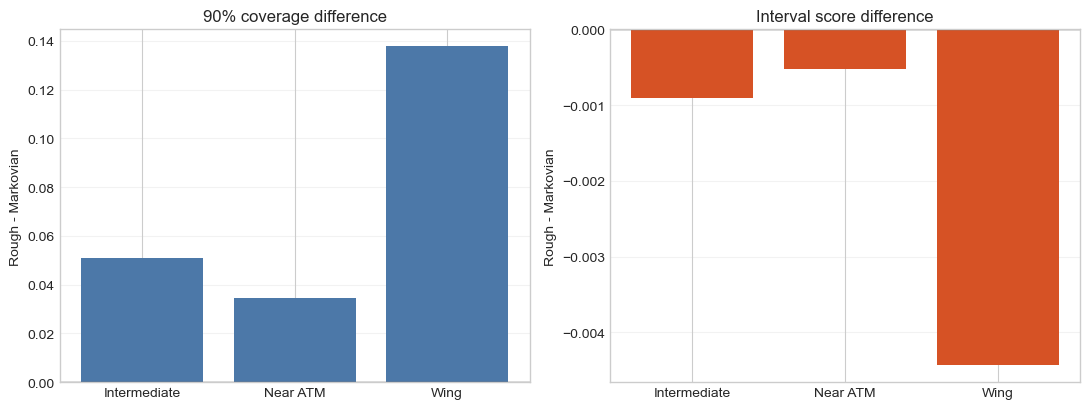

In [14]:
plot_data = moneyness_diff.copy()
regions = plot_data["moneyness_region"].astype(str).tolist()
x = np.arange(len(regions))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(x, plot_data["coverage_90_diff_rough_minus_normal"], color="#4c78a8")
axes[0].axhline(0.0, color="black", linewidth=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions)
axes[0].set_ylabel("Rough - Markovian")
axes[0].set_title("90% coverage difference")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x, plot_data["interval_score_90_diff_rough_minus_normal"], color="#d65225")
axes[1].axhline(0.0, color="black", linewidth=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(regions)
axes[1].set_ylabel("Rough - Markovian")
axes[1].set_title("Interval score difference")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "predictive_calibration_by_moneyness.png", dpi=220, bbox_inches="tight")
plt.show()